In [1]:
# Load environment variables and set up auto-reload
from dotenv import load_dotenv
load_dotenv()

%load_ext autoreload
%autoreload 2

<div class="dark-title" style="background:linear-gradient(90deg,#1e3a8a,#5b21b6); color:#f1f5f9; padding:20px 32px; border-radius:8px; width:97%;"><style>.dark-title strong{color:#fde047;}</style>

## 🧠 Research Supervisor — 多 agent 派单系统

**一句话定位**:**复杂问题拆给子 agent 并行处理**,supervisor 用 **隔离的 context window** 协调,避免单 agent 在多子主题任务上的 context 污染。

</div>

> *Supervisor 的工作很简单:**根据需要,把研究任务派给合适数量的子 agent**。*

整体流程图:

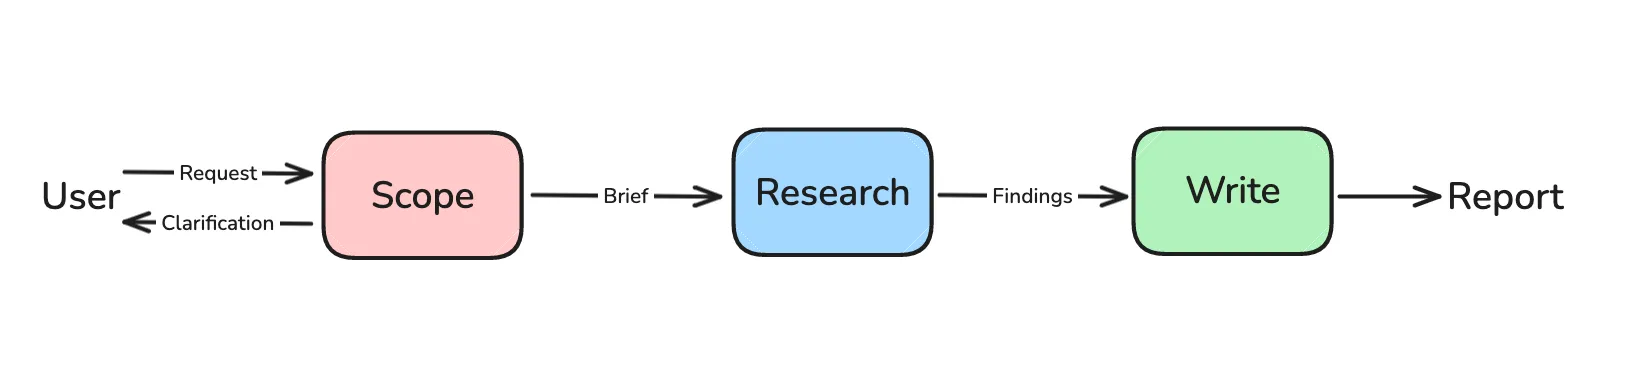

<div class="dark-info" style="background:#1e293b; color:#e2e8f0; padding:12px 24px; border-left:4px solid #60a5fa; border-radius:4px; width:97%;"><style>.dark-info strong{color:#fbbf24;}</style>

**🤔 为什么需要多 agent?**

上一节我们搭好了 **单 research agent**(自定义工具或 MCP)。但 **复杂请求** 怎么办?比如 **「**对比 A、B、C 三个**」**。

**单 agent 在多子主题上的问题**:

- 一个 context window 要 **同时存储和推理** 所有子主题的工具反馈
- 工具反馈通常 **token 密集**
- [常见失败模式](https://www.dbreunig.com/2025/06/22/how-contexts-fail-and-how-to-fix-them.html) 比如 **context clash**(上下文冲突)在多子主题时 **越来越严重**

[Anthropic 的博客](https://www.anthropic.com/engineering/built-multi-agent-research-system) 提到:**multi-agent 系统能把子主题分给子 agent**,每个子 agent **拥有隔离的 context window**。

</div>

我们就搭这样的系统:**supervisor 判断 brief 能否拆成独立子主题,可以的话就派给子 agent,每个子 agent 有自己干净的 context**。

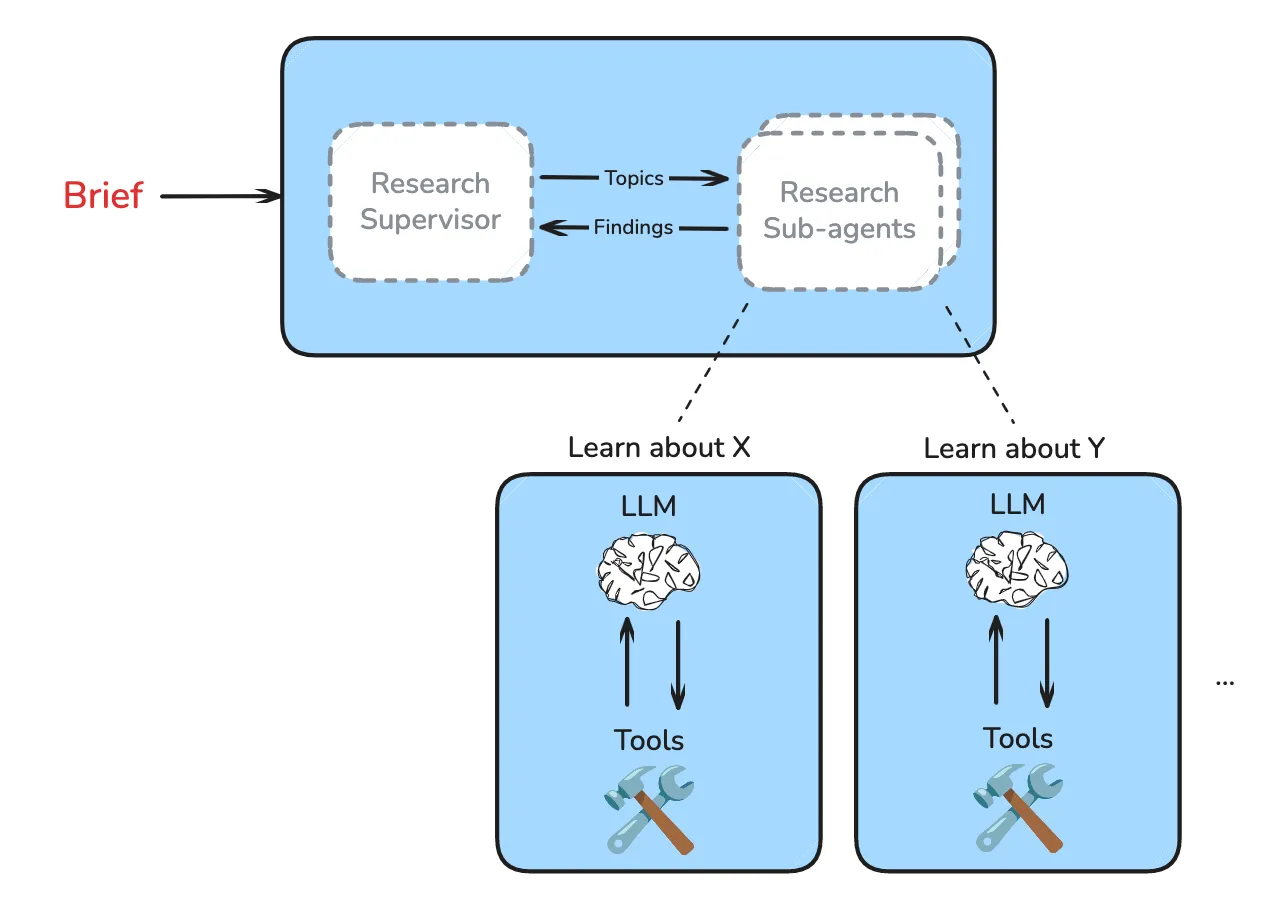

### 📝 Supervisor 的 Prompt 设计

按之前的原则 + [研究文献](https://www.anthropic.com/engineering/built-multi-agent-research-system) 的启发,设计 supervisor 的 prompt:

### ① 像 agent 一样思考

| 指令 | 含义 |
|------|------|
| **仔细读问题** | 用户具体要什么? |
| **决定怎么派单** | 问题有 **可并行的独立方向** 吗? |
| **每次 ConductResearch 调用后暂停评估** | 信息够答了吗?还缺什么? |

### ② 具体启发(派单的硬限制)

| 限制 | 含义 |
|------|------|
| **偏好单 agent** | 除非有 **明确可并行的机会**,否则用单 agent(简单) |
| **能自信回答就停** | 别为了完美无限派单 |
| **3 次硬上限** | ConductResearch 最多 3 次,找不到就停 |

### ③ 展示思考

调 ConductResearch 之前,用 `think_tool` **规划**:

- 任务能拆成更小的子任务吗?

每次 ConductResearch 之后,用 `think_tool` **分析**:

- 找到啥关键信息?
- 还缺什么?
- 够全面回答了吗?
- 继续搜还是给答案?

### ④ 派单规模规则

| 任务类型 | 子 agent 数 | 例子 |
|---------|-----------|------|
| **简单事实查找 / 列表 / 排名** | **1 个** | 「列出 SF 前 10 咖啡馆」 |
| **明确的对比任务** | **每个对比对象 1 个** | 「对比 OpenAI / Anthropic / DeepMind 的 AI 安全做法」 → 3 个子 agent |

<div class="dark-warning" style="background:#2a2418; color:#fde68a; padding:12px 24px; border-left:4px solid #fbbf24; border-radius:4px; width:97%;"><style>.dark-warning strong{color:#f9a8d4;}</style>

**🔑 派单原则:**清晰、独立、不重叠的子主题**

不要硬把一个连贯主题拆成多个子主题派出去 —— **会产生大量重复工作和冲突结论**。如果子主题之间需要相互参考,**就不该拆**。

</div>

In [3]:
import sys
sys.path.append("../src")
from utils import show_prompt
from deep_research_from_scratch.prompts import lead_researcher_prompt
show_prompt(lead_researcher_prompt, "Lead Researcher Prompt")

╭──────────────────────────────────────────── Lead Researcher Prompt ─────────────────────────────────────────────╮
│                                                                                                                 │
│  You are a research supervisor. Your job is to conduct research by calling the "ConductResearch" tool. For      │
│  context, today's date is {date}.                                                                               │
│                                                                                                                 │
│  <Task>                                                                                                         │
│  Your focus is to call the "ConductResearch" tool to conduct research against the overall research question     │
│  passed in by the user.                                                                                         │
│  When you are completely satisfied with the research findings returned from the tool calls, then you should     │
│  call the "ResearchComplete" tool to indicate that you are done with your research.                             │
│  </Task>                                                                                                        │
│                                                                                                                 │
│  <Available Tools>                                                                                              │
│  You have access to three main tools:                                                                           │
│  1. **ConductResearch**: Delegate research tasks to specialized sub-agents                                      │
│  2. **ResearchComplete**: Indicate that research is complete                                                    │
│  3. **think_tool**: For reflection and strategic planning during research                                       │
│                                                                                                                 │
│  **CRITICAL: Use think_tool before calling ConductResearch to plan your approach, and after each                │
│  ConductResearch to assess progress**                                                                           │
│  **PARALLEL RESEARCH**: When you identify multiple independent sub-topics that can be explored simultaneously,  │
│  make multiple ConductResearch tool calls in a single response to enable parallel research execution. This is   │
│  more efficient than sequential research for comparative or multi-faceted questions. Use at most                │
│  {max_concurrent_research_units} parallel agents per iteration.                                                 │
│  </Available Tools>                                                                                             │
│                                                                                                                 │
│  <Instructions>                                                                                                 │
│  Think like a research manager with limited time and resources. Follow these steps:                             │
│                                                                                                                 │
│  1. **Read the question carefully** - What specific information does the user need?                             │
│  2. **Decide how to delegate the research** - Carefully consider the question and decide how to delegate the    │
│  research. Are there multiple independent directions that can be explored simultaneously?                       │
│  3. **After each call to ConductResearch, pause and assess** - Do I have enough to answer? What's still         │
│  missing?                                                                                                       │
│  </Instructions>                                      

### 📦 State 设计

**两层 state**:

| 层 | 作用 |
|----|------|
| **Supervisor state** | 管理 **整体研究协调**(多 agent 协作) |
| **Researcher state** | 处理 **单个研究任务** |

In [4]:
%%writefile ../src/deep_research_from_scratch/state_multi_agent_supervisor.py

"""
State Definitions for Multi-Agent Research Supervisor

This module defines the state objects and tools used for the multi-agent
research supervisor workflow, including coordination state and research tools.
"""

import operator
from typing_extensions import Annotated, TypedDict, Sequence

from langchain_core.messages import BaseMessage
from langchain_core.tools import tool
from langgraph.graph.message import add_messages
from pydantic import BaseModel, Field


class SupervisorState(TypedDict):
    """
    State for the multi-agent research supervisor.

    Manages coordination between supervisor and research agents, tracking
    research progress and accumulating findings from multiple sub-agents.
    """

    # Messages exchanged with supervisor for coordination and decision-making
    supervisor_messages: Annotated[Sequence[BaseMessage], add_messages]
    # Detailed research brief that guides the overall research direction
    research_brief: str
    # Processed and structured notes ready for final report generation
    notes: Annotated[list[str], operator.add] = []
    # Counter tracking the number of research iterations performed
    research_iterations: int = 0
    # Raw unprocessed research notes collected from sub-agent research
    raw_notes: Annotated[list[str], operator.add] = []


@tool
class ConductResearch(BaseModel):
    """Tool for delegating a research task to a specialized sub-agent."""

    research_topic: str = Field(
        description="The topic to research. Should be a single topic, and should be described in high detail (at least a paragraph).",
    )


@tool
class ResearchComplete(BaseModel):
    """Tool for indicating that the research process is complete."""

    pass

Overwriting ../src/deep_research_from_scratch/state_multi_agent_supervisor.py


### 🤖 Multi-agent 实现

**Multi-agent 系统** = 多个 agent **<span style="color: gold">完美</span>协作完成任务** 的系统。

<div class="dark-success" style="background:#1a2e1f; color:#bbf7d0; padding:10px 24px; border-left:4px solid #4ade80; border-radius:4px; width:97%;"><style>.dark-success strong{color:#fbbf24;}</style>

**🎁 主要好处:context isolation(上下文隔离)**

按 [Context Engineering for Agents](https://blog.langchain.com/context-engineering-for-agents/) 的讨论,**每个子 agent 有自己独立的 context**,**避免互相污染**。

具体做法(LangGraph 实现):**派单时调子 agent,子 agent 的 messages 是全新的**(只接收 supervisor 给的描述);完成后只 **回传一段总结** 给 supervisor。

</div>

In [5]:
%%writefile ../src/deep_research_from_scratch/multi_agent_supervisor.py

"""Multi-agent supervisor for coordinating research across multiple specialized agents.

This module implements a supervisor pattern where:
1. A supervisor agent coordinates research activities and delegates tasks
2. Multiple researcher agents work on specific sub-topics independently
3. Results are aggregated and compressed for final reporting

The supervisor uses parallel research execution to improve efficiency while
maintaining isolated context windows for each research topic.
"""

import asyncio

from typing_extensions import Literal

from langchain.chat_models import init_chat_model
from langchain_core.messages import (
    HumanMessage,
    BaseMessage,
    SystemMessage,
    ToolMessage,
    filter_messages,
)
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command

from deep_research_from_scratch.prompts import lead_researcher_prompt
from deep_research_from_scratch.research_agent import researcher_agent
from deep_research_from_scratch.state_multi_agent_supervisor import (
    SupervisorState,
    ConductResearch,
    ResearchComplete,
)
from deep_research_from_scratch.utils import get_today_str, think_tool


def get_notes_from_tool_calls(messages: list[BaseMessage]) -> list[str]:
    """Extract research notes from ToolMessage objects in supervisor message history.

    This function retrieves the compressed research findings that sub-agents
    return as ToolMessage content. When the supervisor delegates research to
    sub-agents via ConductResearch tool calls, each sub-agent returns its
    compressed findings as the content of a ToolMessage. This function
    extracts all such ToolMessage content to compile the final research notes.

    Args:
        messages: List of messages from supervisor's conversation history

    Returns:
        List of research note strings extracted from ToolMessage objects
    """
    return [
        tool_msg.content for tool_msg in filter_messages(messages, include_types="tool")
    ]


# Ensure async compatibility for Jupyter environments
try:
    import nest_asyncio

    # Only apply if running in Jupyter/IPython environment
    try:
        from IPython import get_ipython

        if get_ipython() is not None:
            nest_asyncio.apply()
    except ImportError:
        pass  # Not in Jupyter, no need for nest_asyncio
except ImportError:
    pass  # nest_asyncio not available, proceed without it


# ===== CONFIGURATION =====

supervisor_tools = [ConductResearch, ResearchComplete, think_tool]
supervisor_model = init_chat_model(model="anthropic:claude-sonnet-4-6")
supervisor_model_with_tools = supervisor_model.bind_tools(supervisor_tools)

# System constants
# Maximum number of tool call iterations for individual researcher agents
# This prevents infinite loops and controls research depth per topic
max_researcher_iterations = 6  # Calls to think_tool + ConductResearch

# Maximum number of concurrent research agents the supervisor can launch
# This is passed to the lead_researcher_prompt to limit parallel research tasks
max_concurrent_researchers = 3

# ===== SUPERVISOR NODES =====


async def supervisor(state: SupervisorState) -> Command[Literal["supervisor_tools"]]:
    """Coordinate research activities.

    Analyzes the research brief and current progress to decide:
    - What research topics need investigation
    - Whether to conduct parallel research
    - When research is complete

    Args:
        state: Current supervisor state with messages and research progress

    Returns:
        Command to proceed to supervisor_tools node with updated state
    """
    supervisor_messages = state.get("supervisor_messages", [])

    # Prepare system message with current date and constraints
    system_message = lead_researcher_prompt.format(
        date=get_today_str(),
        max_concurrent_research_units=max_concurrent_researchers,
        max_researcher_iterations=max_researcher_iterations,
    )
    messages = [SystemMessage(content=system_message)] + supervisor_messages

    # Make decision about next research steps
    response = await supervisor_model_with_tools.ainvoke(messages)

    return Command(
        goto="supervisor_tools",
        update={
            "supervisor_messages": [response],
            "research_iterations": state.get("research_iterations", 0) + 1,
        },
    )


async def supervisor_tools(
    state: SupervisorState,
) -> Command[Literal["supervisor", "__end__"]]:
    """Execute supervisor decisions - either conduct research or end the process.

    Handles:
    - Executing think_tool calls for strategic reflection
    - Launching parallel research agents for different topics
    - Aggregating research results
    - Determining when research is complete

    Args:
        state: Current supervisor state with messages and iteration count

    Returns:
        Command to continue supervision, end process, or handle errors
    """
    supervisor_messages = state.get("supervisor_messages", [])
    research_iterations = state.get("research_iterations", 0)
    most_recent_message = supervisor_messages[-1]

    # Initialize variables for single return pattern
    tool_messages = []
    all_raw_notes = []
    next_step = "supervisor"  # Default next step
    should_end = False

    # Check exit criteria first
    exceeded_iterations = research_iterations >= max_researcher_iterations
    no_tool_calls = not most_recent_message.tool_calls
    research_complete = any(
        tool_call["name"] == "ResearchComplete"
        for tool_call in most_recent_message.tool_calls
    )

    if exceeded_iterations or no_tool_calls or research_complete:
        should_end = True
        next_step = END

    else:
        # Execute ALL tool calls before deciding next step
        try:
            # Separate think_tool calls from ConductResearch calls
            think_tool_calls = [
                tool_call
                for tool_call in most_recent_message.tool_calls
                if tool_call["name"] == "think_tool"
            ]

            conduct_research_calls = [
                tool_call
                for tool_call in most_recent_message.tool_calls
                if tool_call["name"] == "ConductResearch"
            ]

            # Handle think_tool calls (synchronous)
            for tool_call in think_tool_calls:
                observation = think_tool.invoke(tool_call["args"])
                tool_messages.append(
                    ToolMessage(
                        content=observation,
                        name=tool_call["name"],
                        tool_call_id=tool_call["id"],
                    )
                )

            # Handle ConductResearch calls (asynchronous)
            if conduct_research_calls:
                # Launch parallel research agents
                coros = [
                    researcher_agent.ainvoke(
                        {
                            "researcher_messages": [
                                HumanMessage(
                                    content=tool_call["args"]["research_topic"]
                                )
                            ],
                            "research_topic": tool_call["args"]["research_topic"],
                        }
                    )
                    for tool_call in conduct_research_calls
                ]

                # Wait for all research to complete
                tool_results = await asyncio.gather(*coros)

                # Format research results as tool messages
                # Each sub-agent returns compressed research findings in result["compressed_research"]
                # We write this compressed research as the content of a ToolMessage, which allows
                # the supervisor to later retrieve these findings via get_notes_from_tool_calls()
                research_tool_messages = [
                    ToolMessage(
                        content=result.get(
                            "compressed_research", "Error synthesizing research report"
                        ),
                        name=tool_call["name"],
                        tool_call_id=tool_call["id"],
                    )
                    for result, tool_call in zip(tool_results, conduct_research_calls)
                ]

                tool_messages.extend(research_tool_messages)

                # Aggregate raw notes from all research
                all_raw_notes = [
                    "\n".join(result.get("raw_notes", [])) for result in tool_results
                ]

        except Exception as e:
            print(f"Error in supervisor tools: {e}")
            should_end = True
            next_step = END

    # Single return point with appropriate state updates
    if should_end:
        return Command(
            goto=next_step,
            update={
                "notes": get_notes_from_tool_calls(supervisor_messages),
                "research_brief": state.get("research_brief", ""),
            },
        )
    else:
        return Command(
            goto=next_step,
            update={"supervisor_messages": tool_messages, "raw_notes": all_raw_notes},
        )


# ===== GRAPH CONSTRUCTION =====

# Build supervisor graph
supervisor_builder = StateGraph(SupervisorState)
supervisor_builder.add_node("supervisor", supervisor)
supervisor_builder.add_node("supervisor_tools", supervisor_tools)
supervisor_builder.add_edge(START, "supervisor")
supervisor_agent = supervisor_builder.compile()

Overwriting ../src/deep_research_from_scratch/multi_agent_supervisor.py


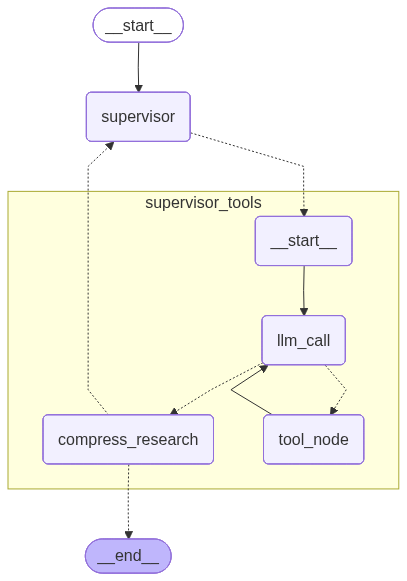

In [6]:
from IPython.display import Image, display
from deep_research_from_scratch.multi_agent_supervisor import supervisor_agent

# Show the agent
display(Image(supervisor_agent.get_graph(xray=True).draw_mermaid_png()))

In [8]:
# Run the multi-agent supervisor agent
from utils import format_messages
from langchain_core.messages import HumanMessage

research_brief = """I want to identify and evaluate the coffee shops in San Francisco that are considered the best based specifically  
on coffee quality. My research should focus on analyzing and comparing coffee shops within the San Francisco area, 
using coffee quality as the primary criterion. I am open regarding methods of assessing coffee quality (e.g.,      
expert reviews, customer ratings, specialty coffee certifications), and there are no constraints on ambiance,      
location, wifi, or food options unless they directly impact perceived coffee quality. Please prioritize primary    
sources such as the official websites of coffee shops, reputable third-party coffee review organizations (like     
Coffee Review or Specialty Coffee Association), and prominent review aggregators like Google or Yelp where direct  
customer feedback about coffee quality can be found. The study should result in a well-supported list or ranking of
the top coffee shops in San Francisco, emphasizing their coffee quality according to the latest available data as  
of July 2025."""

result = await supervisor_agent.ainvoke(
    {"supervisor_messages": [HumanMessage(content=f"{research_brief}.")]}
)
format_messages(result["supervisor_messages"])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ I want to identify and evaluate the coffee shops in San Francisco that are considered the best based            │
│ specifically                                                                                                    │
│ on coffee quality. My research should focus on analyzing and comparing coffee shops within the San Francisco    │
│ area,                                                                                                           │
│ using coffee quality as the primary criterion. I am open regarding methods of assessing coffee quality (e.g.,   │
│ expert reviews, customer ratings, specialty coffee certifications), and there are no constraints on ambiance,   │
│ location, wifi, or food options unless they directly impact perceived coffee quality. Please prioritize primary │
│ sources such as the official websites of coffee shops, reputable third-party coffee review organizations (like  │
│ Coffee Review or Specialty Coffee Association), and prominent review aggregators like Google or Yelp where      │
│ direct                                                                                                          │
│ customer feedback about coffee quality can be found. The study should result in a well-supported list or        │
│ ranking of                                                                                                      │
│ the top coffee shops in San Francisco, emphasizing their coffee quality according to the latest available data  │
│ as                                                                                                              │
│ of July 2025..                                                                                                  │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│ 🔧 Tool Call: think_tool                                                                                        │
│    Args: {                                                                                                      │
│   "reflection": "The user wants a comprehensive ranking of the best coffee shops in San Francisco based         │
│ specifically on coffee quality. They want:\n1. Primary sources: official coffee shop websites, Coffee Review,   │
│ Specialty Coffee Association, Google/Yelp reviews\n2. Focus on coffee quality (expert reviews, customer         │
│ ratings, specialty coffee certifications)\n3. Latest available data as of July 2025\n\nThis is a research task  │
│ that can benefit from parallel research across different source types:\n1. Expert reviews and specialty coffee  │
│ certifications (Coffee Review, SCA, barista championships, specialty coffee community)\n2. Aggregator/customer  │
│ review data (Google, Yelp ratings focused on coffee quality)\n3. Editorial/curated lists from reputable         │
│ food/coffee publications (Eater SF, SFGate, Serious Eats, local publications)\n\nI'll run 3 parallel agents to  │
│ cover these distinct angles simultaneously."                                                                    │
│ }                                                                                                               │
│    ID: toolu_01JNFvbfCsHWzgrQPUUQRnWi                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Reflection recorded: The user wants a comprehensive ranking of the best coffee shops in San Francisco based     │
│ specifically on coffee quality. They want:                                                                      │
│ 1. Primary sources: official coffee shop websites, Coffee Review, Specialty Coffee Association, Google/Yelp     │
│ reviews                                                                                                         │
│ 2. Focus on coffee quality (expert reviews, customer ratings, specialty coffee certifications)                  │
│ 3. Latest available data as of July 2025                                                                        │
│                                                                                                                 │
│ This is a research task that can benefit from parallel research across different source types:                  │
│ 1. Expert reviews and specialty coffee certifications (Coffee Review, SCA, barista championships, specialty     │
│ coffee community)                                                                                               │
│ 2. Aggregator/customer review data (Google, Yelp ratings focused on coffee quality)                             │
│ 3. Editorial/curated lists from reputable food/coffee publications (Eater SF, SFGate, Serious Eats, local       │
│ publications)                                                                                                   │
│                                                                                                                 │
│ I'll run 3 parallel agents to cover these distinct angles simultaneously.                                       │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│ 🔧 Tool Call: ConductResearch                                                                                   │
│    Args: {                                                                                                      │
│   "research_topic": "Research the best coffee shops in San Francisco based on expert reviews and specialty      │
│ coffee certifications as of 2024-2025. Focus on: (1) Coffee Review (coffeereview.com) scores and reviews of San │
│ Francisco coffee roasters and shops, (2) Specialty Coffee Association recognition or awards for San Francisco   │
│ coffee shops or roasters, (3) recognition from the Specialty Coffee Association of America, (4) any barista     │
│ championship wins or competition results tied to San Francisco coffee shops, (5) mentions in specialty coffee   │
│ industry publications such as Sprudge.com or Perfect Daily Grind. List specific shop names, their scores or     │
│ certifications, and the source of each claim."                                                                  │
│ }                                                                                                               │
│    ID: toolu_01NrAyTTsaLkN5Ch6CsCnoXs                                                                           │
│                                                                                                                 │
│ 🔧 Tool Call: ConductResearch                                                                                   │
│    Args: {                                                                                                      │
│   "research_topic": "Research the top-rated coffee shops in San Francisco on Google Maps and Yelp as of         │
│ 2024-2025, specifically filtering for coffee quality. Find shops that: (1) have high overall star ratings (4.5  │
│ stars or above) with a large volume of reviews on Google or Yelp, (2) have customer reviews that specifically   │
│ praise coffee quality, espresso, pour-over, or brewing technique (not just ambiance or food), (3) appear on     │
│ Yelp's \"Best Coffee and Tea\" category in San Francisco sorted by rating. List the top 10-15 shops with their  │
│ ratings, number of reviews, and specific coffee-quality-related customer feedback quotes if available."         │
│ }                                                                                                               │
│    ID: toolu_01Ei7MKTFLf3LGLzA9TYPCEx                                                                           │
│                                                                                                                 │
│ 🔧 Tool Call: ConductResearch                                                                                   │
│    Args: {                                                                                                      │
│   "research_topic": "Research editorial and curated \"best coffee shops in San Francisco\" lists from reputable │
│ food, lifestyle, and coffee publications as of 2024-2025. Sources to check include: Eater SF (eater.com/sf),    │
│ SFGate, San Francisco Chronicle, Bon App\u00e9tit, Food and Wine, Serious Eats, Conde Nast Traveler, Time Out   │
│ San Francisco, and Infatuation SF. Focus specifically on shops praised for coffee quality (not just atmosphere  │
│ or food). List which shops appear most frequently across multiple publications, what specific coffee offerings  │
│ are highlighted (e.g., single-origin espresso, natural process beans, skilled latte art, exceptional            │
│ pour-over), and note any shops that have recently opened or gained recognition in 2024-2025."                   │
│ }                                                         

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ **List of Queries and Tool Calls Made**                                                                         │
│                                                                                                                 │
│ 1. Searched for Coffee Review (coffeereview.com) scores and reviews of San Francisco coffee roasters and shops, │
│ 2024–2025.                                                                                                      │
│ 2. Searched for Specialty Coffee Association awards/recognition for San Francisco coffee shops (2024–2025).     │
│ 3. Searched for mentions in specialty coffee industry publications such as Sprudge.com or Perfect Daily Grind.  │
│ 4. Searched for Coffee Review scores specific to Ritual, Verve, Sightglass, Linea, Wrecking Ball, etc.          │
│ 5. Searched for US Barista Championship and World Barista Championship winners from San Francisco.              │
│ 6. Searched Sprudge for San Francisco coffee shops, 2024–2025 best lists.                                       │
│ 7. Searched for Perfect Daily Grind coverage of San Francisco coffee shops.                                     │
│ 8. Searched for Equator Coffees’ SCA/B-Corp certifications.                                                     │
│ 9. Searched for specific Coffee Review high scores for SF roasters (94+).                                       │
│ 10. Searched for Sprudge award winners and barista championship placements tied to San Francisco shops.         │
│ 11. Searched for more public records about barista competition participants from San Francisco.                 │
│ 12. Searched for information on other notable coffee shops (Eater SF and SF Chronicle guides).                  │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ **Fully Comprehensive Findings**                                                                                │
│                                                                                                                 │
│ 1. **Coffee Review (coffeereview.com) San Francisco Scores & Reviews (2024–2025)**                              │
│                                                                                                                 │
│ - The webpage from Coffee Review offers detailed evaluations of 265 coffee and espresso products roasted in the │
│ greater San Francisco area, presented in reverse chronological order. It features thorough tasting notes,       │
│ pricing, and expert descriptions focused on flavor profiles, mouthfeel, and finish. Notable recent reviews      │
│ include 'Hibiscus Dream Colombia Granja Paraiso 92 Red Bourbon Sugarcane Decaf' with a score of 91, highlighted │
│ for its citrusy and floral notes; Equator Coffees' 'Decaf Suke Quto' and 'Dipsea Espresso', both rated 93,      │
│ praised for their refreshing and cocoa-forward flavors respectively. The site also gives high praise to Equator │
│ Coffees and Souvenir Coffee offerings, underlining complex, rich aromas and balanced acidity. Each review       │
│ provides a price per 12 ounces (or 16 ounces where indicated), review date, and direct links for full reviews   │
│ and coffee roasters’ websites. This resource serves coffee enthusiasts looking for expert assessments of San    │
│ Francisco's top quality coffees, combining sensory descriptions with scoring to guide selection.[1]             │
│                                                                                                                 │
│ - Coffee Review is a leading online guide dedicated to 

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ **List of Queries and Tool Calls Made**                                                                         │
│                                                                                                                 │
│ 1. Searched for "top rated coffee shops San Francisco 2024 2025 Google Maps Yelp 4.5 stars coffee quality."     │
│ 2. Searched for "Yelp best coffee and tea San Francisco 2024 highest rated most reviewed."                      │
│ 3. Searched for "Saint Frank Coffee San Francisco Yelp Google rating reviews espresso pour over quality 2024."  │
│ 4. Searched for "best San Francisco coffee shops 2024 2025 Yelp ratings stars reviews Ritual Sightglass Linea   │
│ Wrecking Ball Andytown."                                                                                        │
│ 5. Searched for "Linea Caffe Wrecking Ball Pinhole Coffee Andytown Ritual San Francisco Yelp Google Maps star   │
│ rating review count 2024 2025."                                                                                 │
│ 6. Searched for "\"San Francisco\" coffee shop customer review \"best espresso\" OR \"best pour over\" OR       │
│ \"best latte\" OR \"coffee quality\" Yelp 2024 2025."                                                           │
│ 7. Searched for "Pinhole Coffee \"Grand Coffee\" \"Paper Son\" \"The Coffee Movement\" San Francisco Yelp       │
│ rating reviews espresso coffee quality 2024."                                                                   │
│ 8. Searched for "best San Francisco coffee shops 2024 2025 Google Maps rating \"4.5\" OR \"4.6\" OR \"4.7\" OR  │
│ \"4.8\" espresso pour over specialty coffee reviews."                                                           │
│ 9. Searched for "Ritual Coffee Roasters Sightglass Flywheel \"Wrecking Ball\" \"Andytown\" San Francisco Yelp   │
│ stars reviews \"espresso\" \"pour over\" \"brewing\" customer review quote 2024 2025."                          │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ **Fully Comprehensive Findings**                                                                                │
│                                                                                                                 │
│ - Source 1 (YouTube - Navigate with Kate, April 13, 2025): Guide highlights 16 must-visit coffee shops in San   │
│ Francisco, categorized into Work-Friendly (Blue Bottle Coffee, Bluestone Lane, Andytown Coffee, Equator         │
│ Coffees, Flywheel Coffee Roasters), Roasters (Linea Coffee Roasters, Sextant Coffee Roasters, Ritual Coffee     │
│ Roasters), Design & Unique Shops (P-Town Coffee, Transamerica Pyramid, Post Script Coffee), Top 5 Specialty     │
│ Cafes (The Coffee Movement, Moaring Coffee, Paper Moon Coffee, Saint Frank Coffee, The Mill). Details include   │
│ atmosphere, coffee quality, offerings (including unique brewing methods), and design. Notable mentions: Blue    │
│ Bottle's iconic status, Ritual & Sextant for quality beans and neighborhood vibe, The Mill's bread and coffee.  │
│ [1]                                                                                                             │
│                                                                                                                 │
│ - Source 2 (Sugar & Stamps): Best coffee shops in San Francisco include Andytown Coffee Roasters (Snowy Plover  │
│ coffee float), Blue Bottle Coffee (expertly sourced single origins, Ferry Building), Cafe Réveille (brunch,     │
│ outdoor seating), Flywheel Coffee Roasters (handcrafted

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ **List of Queries and Tool Calls Made**                                                                         │
│                                                                                                                 │
│ 1. Search for “best coffee shops San Francisco 2024 2025 Eater SF SFGate Chronicle recommendations” [1]         │
│ 2. Search for “best coffee San Francisco 2024 Bon Appetit Food Wine Serious Eats Conde Nast Traveler” [2]       │
│ 3. Search for “Infatuation SF best coffee shops San Francisco 2024 2025” [3]                                    │
│ 4. Search for “Time Out San Francisco best coffee shops 2024 2025 SFGate Chronicle coffee guide” [4]            │
│ 5. Search for “Infatuation best coffee shops San Francisco site:theinfatuation.com” [5]                         │
│ 6. Search for “'best coffee' 'San Francisco' 2024 2025 Serious Eats OR 'Food and Wine' OR 'Bon Appetit'         │
│ specialty espresso pour-over” [6]                                                                               │
│ 7. Search for “new coffee shops San Francisco 2024 2025 opened best recently Komakase Third Wheel Heyma Paper   │
│ Son” [7]                                                                                                        │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ **Fully Comprehensive Findings**                                                                                │
│                                                                                                                 │
│ San Francisco is and has been for many the world over the summit of coffee culture. It's the birthplace of      │
│ Wrecking Ball Coffee, where Trish Rothgeb introduced the 'waves of coffee' terminology and changed the industry │
│ forever. These 17 coffee shops keep the torch burning, making those great ascents into the future. Saint Frank  │
│ is to San Francisco coffee as Dungeness crab is to San Francisco restaurants: when the time is right in the     │
│ city, nothing else will do. Paper Son pop-up is a crowning achievement in the city’s vast coffee game, merging  │
│ his Asian American heritage with his top-tier espresso and pour-over skills. [1]                                │
│                                                                                                                 │
│ The Eater San Francisco webpage, authored by Paolo Bicchieri and updated in 2026, presents a comprehensive      │
│ guide to the best coffee shops in San Francisco, a city renowned as a global coffee culture hub. It highlights  │
│ the historical significance of San Francisco in coffee innovation, including the birthplace of Wrecking Ball    │
│ Coffee's "waves of coffee" concept, the introduction of Yemeni coffee on the West Coast, the origin of Irish    │
│ Coffee, and the invention of vacuum-sealed coffee. The guide lists 17 top coffee shops, noting recent changes   │
│ with six shops rotating off and six new ones joining the list. Each café is briefly described with location,    │
│ specialties, and unique contributions to the local coffee scene. Notable featured establishments include Caffe  │
│ Trieste, a historic spot favored by Francis Ford Coppola; Capital One Cafe known for remote work amenities and  │
│ Verve Coffee beans; Cafe Shoji which offers award-winning MAME coffee; Paper Son blending Asian American        │
│ heritage with specialty coffee; Hi NRG with Hong Kong-inspired lattes and vibrant atmosphere; Delah Coffee      │
│ House pioneering Yemeni coffee in the city; Golden Goat

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│ 🔧 Tool Call: think_tool                                                                                        │
│    Args: {                                                                                                      │
│   "reflection": "Excellent! I now have very comprehensive research from three parallel agents covering:\n\n1.   │
│ **Expert/Specialty Sources**: Coffee Review scores (93-95 range for specific SF roasters/shops), SCA            │
│ certifications, barista championship results (2025 US Barista Championship had TWO San Francisco finalists -    │
│ Circle Chan from The Coffee Movement and Jason Yeo from Saint Frank Coffee), Sprudge mentions, Equator B-Corp   │
│ certification, Linea Caffe's award-winning espresso, Sightglass Owl's Howl espresso scoring 93 on Coffee        │
│ Review.\n\n2. **Review Aggregator Data**: Sightglass (4.0, 2,200+ reviews), Ritual Coffee (~4.0-4.5, ~1,995     │
│ reviews), Andytown (1,100+ reviews), Four Barrel, Linea Caffe (264 reviews), Wrecking Ball, Pinhole Coffee (294 │
│ reviews), The Coffee Movement (272 reviews), Paper Son (70 reviews), Grand Coffee, Home Coffee Roasters (1,552+ │
│ reviews). Customer quotes about coffee quality collected.\n\n3. **Editorial Lists**: Eater SF's 17 best         │
│ (updated 2026) includes Saint Frank, Linea, Paper Son, Hi NRG, Delah, Golden Goat, The Coffee Movement, Grand   │
│ Coffee, Pinhole, Excelsior, Caffe Trieste, Better Half, Hedge Coffee, Sightglass. The Infatuation's list        │
│ includes The Coffee Movement, Saint Frank, Andytown, Pinhole, Paper Son, Kompton's Coffee House, Grand Coffee,  │
│ Caffe Trieste, Snowbird, Home Coffee Roasters. Time Out SF includes Andytown, Equator, Sightglass, Ritual,      │
│ Saint Frank, Philz, Blue Bottle. SF Chronicle/SFGate also referenced.\n\nKey findings for ranking:\n- **Saint   │
│ Frank Coffee**: Appears on virtually every list, US Barista Championship finalist (Jason Yeo, 2025), first to   │
│ introduce Kaffe Tonic in California, described as \"to SF coffee as Dungeness crab is to SF restaurants\" -     │
│ this is consistently the #1 most-mentioned top-tier shop\n- **Linea Caffe**: \"Award-winning coffees +          │
│ espresso,\" eco-friendly, on Sprudge, on Eater, on Infatuation, specialty-focused Mission location\n- **The     │
│ Coffee Movement**: 2025 US Barista Championship finalist (Circle Chan), described as \"O.G. specialty coffee    │
│ shop in SF,\" Coffee Review-level quality, multi-roaster, tasting flights, strong customer reviews\n- **Ritual  │
│ Coffee Roasters**: Pioneer SF specialty roaster, nearly 2,000 reviews, sommelier-style approach to sourcing,    │
│ consistently on editorial lists\n- **Sightglass Coffee**: Coffee Review score 93 for Owl's Howl Espresso Blend, │
│ USDA Certified Organic, 2,200+ reviews, on nearly every list, multiple locations\n- **Andytown Coffee           │
│ Roasters**: Consistently ranked, 1,100+ reviews, praised for single-origin espresso, ethically sourced beans,   │
│ Snowy Plover signature\n- **Wrecking Ball Coffee Roasters**: Historic importance (Trish Rothgeb coined \"third  │
│ wave\" there), sustainably sourced specialty\n- **Equator Coffees**: B-Corp certified, Coffee Review scores 93  │
│ for two coffees, Roaster of the Year 2010, Good Food Award winner\n- **Paper Son Coffee**: New, highly praised  │
│ by Eater and specialty press, barista Alex Pong's espresso and pour-over skills\n- **Grand Coffee**: Mission    │
│ neighborhood staple, praised for espresso consistency\n- **Pinhole Coffee**: Fruity/inventive, on Eater and     │
│ Infatuation\n- **Excelsior Coffee**: Strong pulls, underrated gem per Eater\n- **Hi NRG**: Described as #1      │
│ specialty discovery by specialty coffee blogger, owner-o

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Reflection recorded: Excellent! I now have very comprehensive research from three parallel agents covering:     │
│                                                                                                                 │
│ 1. **Expert/Specialty Sources**: Coffee Review scores (93-95 range for specific SF roasters/shops), SCA         │
│ certifications, barista championship results (2025 US Barista Championship had TWO San Francisco finalists -    │
│ Circle Chan from The Coffee Movement and Jason Yeo from Saint Frank Coffee), Sprudge mentions, Equator B-Corp   │
│ certification, Linea Caffe's award-winning espresso, Sightglass Owl's Howl espresso scoring 93 on Coffee        │
│ Review.                                                                                                         │
│                                                                                                                 │
│ 2. **Review Aggregator Data**: Sightglass (4.0, 2,200+ reviews), Ritual Coffee (~4.0-4.5, ~1,995 reviews),      │
│ Andytown (1,100+ reviews), Four Barrel, Linea Caffe (264 reviews), Wrecking Ball, Pinhole Coffee (294 reviews), │
│ The Coffee Movement (272 reviews), Paper Son (70 reviews), Grand Coffee, Home Coffee Roasters (1,552+ reviews). │
│ Customer quotes about coffee quality collected.                                                                 │
│                                                                                                                 │
│ 3. **Editorial Lists**: Eater SF's 17 best (updated 2026) includes Saint Frank, Linea, Paper Son, Hi NRG,       │
│ Delah, Golden Goat, The Coffee Movement, Grand Coffee, Pinhole, Excelsior, Caffe Trieste, Better Half, Hedge    │
│ Coffee, Sightglass. The Infatuation's list includes The Coffee Movement, Saint Frank, Andytown, Pinhole, Paper  │
│ Son, Kompton's Coffee House, Grand Coffee, Caffe Trieste, Snowbird, Home Coffee Roasters. Time Out SF includes  │
│ Andytown, Equator, Sightglass, Ritual, Saint Frank, Philz, Blue Bottle. SF Chronicle/SFGate also referenced.    │
│                                                                                                                 │
│ Key findings for ranking:                                                                                       │
│ - **Saint Frank Coffee**: Appears on virtually every list, US Barista Championship finalist (Jason Yeo, 2025),  │
│ first to introduce Kaffe Tonic in California, described as "to SF coffee as Dungeness crab is to SF             │
│ restaurants" - this is consistently the #1 most-mentioned top-tier shop                                         │
│ - **Linea Caffe**: "Award-winning coffees + espresso," eco-friendly, on Sprudge, on Eater, on Infatuation,      │
│ specialty-focused Mission location                                                                              │
│ - **The Coffee Movement**: 2025 US Barista Championship finalist (Circle Chan), described as "O.G. specialty    │
│ coffee shop in SF," Coffee Review-level quality, multi-roaster, tasting flights, strong customer reviews        │
│ - **Ritual Coffee Roasters**: Pioneer SF specialty roaster, nearly 2,000 reviews, sommelier-style approach to   │
│ sourcing, consistently on editorial lists                                                                       │
│ - **Sightglass Coffee**: Coffee Review score 93 for Owl's Howl Espresso Blend, USDA Certified Organic, 2,200+   │
│ reviews, on nearly every list, multiple locations                                                               │
│ - **Andytown Coffee Roasters**: Consistently ranked, 1,100+ reviews, praised for single-origin espresso,        │
│ ethically sourced beans, Snowy Plover signature                                                                 │
│ - **Wrecking Ball Coffee Roasters**: Historic importanc

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│ 🔧 Tool Call: ResearchComplete                                                                                  │
│    Args: {}                                                                                                     │
│    ID: toolu_0187ncMe9Q2FLY6968UXwwn5                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

执行 trace 看 [这里](https://smith.langchain.com/public/99eaaecd-fd9a-4ead-8eed-abdfe4ab9288/r)。

### 🚀 LangGraph Studio

跟之前一样,LangGraph Studio 可视化 agent。

`langgraph.json` 里选 `research_agent_supervisor`:

```json
"research_agent_supervisor": "./src/deep_research_from_scratch/multi_agent_supervisor.py:supervisor_agent",
```

启动:

```bash
uvx --refresh --from "langgraph-cli[inmem]" --with-editable . --python 3.11 langgraph dev --allow-blocking
```

## 🧪 Eval — 测 supervisor 派单的判断

<div class="dark-info" style="background:#1e293b; color:#e2e8f0; padding:12px 24px; border-left:4px solid #60a5fa; border-radius:4px; width:97%;"><style>.dark-info strong{color:#fbbf24;}</style>

**🎯 Multi-agent 的关键好处**:**有明显可分子主题时,context isolation 提升质量**。

引用 [LangChain blog](https://blog.langchain.com/open-deep-research/):

> 「我们的实验显示:**单 agent 在多子主题请求上质量下降**(例如对比 A vs B vs C)。直觉很直接 —— 单 context window 要存所有子主题的工具反馈,而反馈通常 token 密集。Context window 累积多子主题 tool 调用时,**context clash 等失败模式越来越普遍**。」

</div>

<div class="dark-error" style="background:#2d1f1f; color:#fca5a5; padding:10px 24px; border-left:4px solid #f87171; border-radius:4px; width:97%;"><style>.dark-error strong{color:#fde047;}</style>

**⚠️ 但小心不要在不需要时也派子 agent**

引用同样博客:

> 「Supervisor 通过 **选择性派发** 子 agent 来 **调节研究深度**。supervisor 用启发式判断 **什么时候该并行、什么时候单线就够**。我们的 deep research agent 有 **灵活性决定是否并行**。」

</div>

下面做几个测试,确保 **「**能并行才并行**」**。

In [7]:
# Example messages with think_tool calls and tool messages for evaluation
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage

should_parallelize = [
    HumanMessage(content="Compare OpenAI vs Gemini deep research."),
    AIMessage(content="I need to analyze this request to determine if can should be parallelized.", tool_calls=[
        {
            "name": "think_tool",
            "args": {"reflection": "This is a comparison task involving two distinct AI products: OpenAI v Gemini Deep Research."},
            "id": "call_think_1"
        }
    ]),
    ToolMessage(content="Analysis complete: This is a comparison task involving two distinct AI products: OpenAI v Gemini Deep Research.", tool_call_id="call_think_1", name="think_tool")
]

should_not_parallelize = [
    HumanMessage(content="What are the top three Chinese restaurants in Chelsea, Manhattan"),
    AIMessage(content="Let me think about whether this task requires parallelization.", tool_calls=[
        {
            "name": "think_tool", 
            "args": {"reflection": "This is a ranking/listing task for restaurants in a specific geographic area (Chelsea, Manhattan)."},
            "id": "call_think_2"
        }
    ]),
    ToolMessage(content="Analysis complete: This is a ranking/listing task for restaurants in a specific geographic area (Chelsea, Manhattan).", tool_call_id="call_think_2", name="think_tool")
]

In [23]:
import os
from langsmith import Client

# Initialize client 
langsmith_client = Client(api_key=os.getenv("LANGSMITH_API_KEY"))

# Create the dataset
dataset_name = "deep_research_supervisor_parallelism"
if not langsmith_client.has_dataset(dataset_name=dataset_name):

    dataset = langsmith_client.create_dataset(
        dataset_name=dataset_name,
        description="A dataset that evaluates whether a supervisor can accurately decide when to parallelize research.",
    )

    langsmith_client.create_examples(
        dataset_id=dataset.id,
        examples=[
            {
                "inputs": {"supervisor_messages": should_parallelize},
                "outputs": {"num_expected_threads": 2},
            },
            {
                "inputs": {"supervisor_messages": should_not_parallelize},
                "outputs": {"num_expected_threads": 1},
            },
        ],
    )

现在跑评估。

In [9]:
import uuid

def evaluate_parallelism(outputs: dict, reference_outputs:dict):
    tool_calls = outputs["output"].update["supervisor_messages"][-1].tool_calls
    return {
        "key": "correct_next_step",
        "score": len(tool_calls) == reference_outputs["num_expected_threads"]
    }

async def target_func(inputs: dict):
    config = {"configurable": {"thread_id": uuid.uuid4()}}
    return await supervisor_agent.nodes["supervisor"].ainvoke(inputs, config=config)

await langsmith_client.aevaluate(
    target_func,
    data=dataset_name,
    evaluators=[evaluate_parallelism],
    experiment_prefix="Supervisor Parallelism",
)

View the evaluation results for experiment: 'Supervisor Parallelism-b4e2c6e6' at:
https://smith.langchain.com/o/ebbaf2eb-769b-4505-aca2-d11de10372a4/datasets/87d6f859-3fc2-4727-a213-4106ef8851ae/compare?selectedSessions=a7113523-bfbb-472b-bf37-810ae9f22e09




0it [00:00, ?it/s]

<AsyncExperimentResults Supervisor Parallelism-b4e2c6e6>

### 📊 测试结果分析

| 测试 | 期望行为 | 原因 |
|------|---------|------|
| **例 1**:产品对比 | **并行** 派多个子 agent | 每个产品独立深挖,综合时再合并 |
| **例 2**:Chelsea 区 top 餐厅 | **单线** 研究 | 排名类任务,不存在明显可并行点 |

<div class="dark-success" style="background:#1a2e1f; color:#bbf7d0; padding:10px 24px; border-left:4px solid #4ade80; border-radius:4px; width:97%;"><style>.dark-success strong{color:#fbbf24;}</style>

✨ **学到的关键判断**

- **「对比 / 比较 / 评价多个」** → 适合并行 → multi-agent
- **「列出 / 排名 / 推荐」** → 单线足够 → 不需要派单

prompt 写好启发,让 supervisor **自己判断**;eval 用来 **验证判断对不对**。

</div>